In [148]:
import torch
import patterson_utils as pu
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns



In [149]:
path = '/home/arthur/xray_ml/pxrd_sim/src/pxrd_simulator/patterson_10_15_12_set'

anno = pd.read_csv(os.path.join(path, 'test.csv'))
data_path = os.path.join(path, 'data')
anno.head()

,filename,group,unit_cell
0,360000.npz,P 1 21 1 (No. 4),"{'a': 5.792438162399189, 'b': 7.53016961111894..."
1,360001.npz,C 1 2 1 (No. 5),"{'a': 8.214566293437898, 'b': 10.6789361814692..."
2,360002.npz,P 1 21 1 (No. 4),"{'a': 7.168084244645268, 'b': 9.31850951803884..."
3,360003.npz,C 1 2 1 (No. 5),"{'a': 8.822760488090353, 'b': 11.4695886345174..."
4,360004.npz,C 1 2 1 (No. 5),"{'a': 8.489821022170318, 'b': 11.0367673288214..."


In [150]:
random_file = anno.iloc[0]['filename']
full_path = os.path.join(data_path, random_file)

data = np.load(full_path, allow_pickle = True)

data.keys()

KeysView(NpzFile '/home/arthur/xray_ml/pxrd_sim/src/pxrd_simulator/patterson_10_15_12_set/data/360000.npz' with keys: Patt_high, Patt_low)

In [151]:
print(data['Patt_high'].shape, data['Patt_low'].shape)

(24, 24, 24) (12, 12, 12)


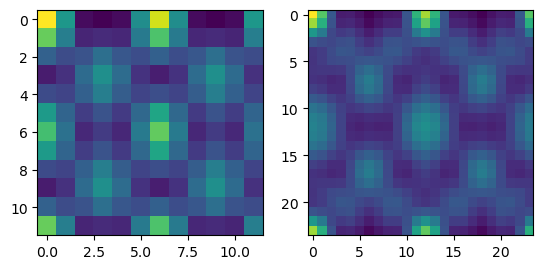

In [152]:
fig, ax = plt.subplots(1, 2)
ax[0].imshow(data['Patt_low'].mean(axis = -1))
ax[1].imshow(data['Patt_high'].mean(axis = -1))
plt.show()


In [153]:
from models.model_patt import *

model = SuperResolutionUnet()
curdir = os.path.abspath(os.curdir)
path_to_dic = os.path.join(curdir, 'experiments/unet_better_upsample_5feb/unet_better_upsample_5feb/model.ckpt')
dic = torch.load(path_to_dic)['state_dict']
dic = {k.replace('model.', ''): v for k, v in dic.items()}
model.load_state_dict(dic)

model.eval()

SuperResolutionUnet(
  (down_blocks): ModuleList(
    (0): DownBlock(
      (double_conv): DoubleConv(
        (double_conv): Sequential(
          (0): Conv3d(1, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): GELU(approximate='none')
          (3): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (4): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (5): GELU(approximate='none')
        )
      )
      (down_sample): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): DownBlock(
      (double_conv): DoubleConv(
        (double_conv): Sequential(
          (0): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (1): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): GEL

In [154]:
low = data['Patt_low']
high = data['Patt_high']
assert low.min() == high.min() == 0 and low.max() == high.max() == 1
low_torch = torch.from_numpy(low).unsqueeze(0).unsqueeze(0).float()
high_torch = torch.from_numpy(high).unsqueeze(0).unsqueeze(0).float()

with torch.no_grad():
    recon = model(low_torch)

recon = recon.squeeze(0).squeeze(0).cpu().detach().numpy()


In [155]:
print(recon.min(), recon.max())
#if recon.min() < 0 or recon.max() != 1:
#    recon = (recon - recon.min()) / (recon.max() - recon.min())

print('after setting zeros:', recon.min(), recon.max())


-0.0021634991 0.29922843
after setting zeros: -0.0021634991 0.29922843


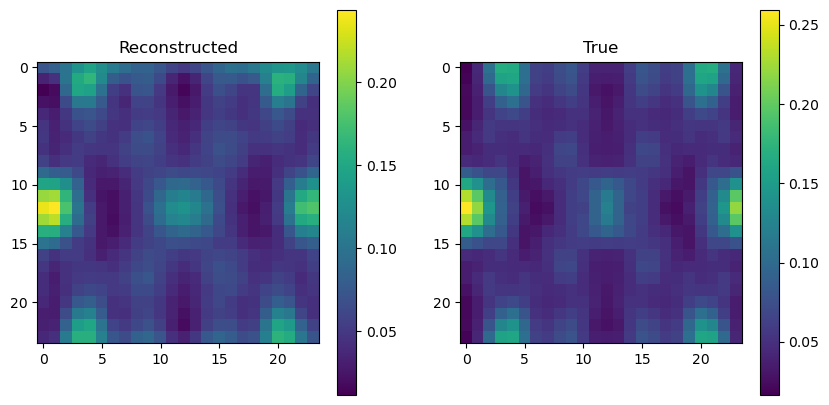

In [156]:
fig, ax = plt.subplots(1, 2, figsize = (10, 5))
ax[0].imshow(recon.mean(axis = -1))
ax[0].set_title('Reconstructed')
ax[1].imshow(high.mean(axis = -1))
ax[1].set_title('True')
fig.colorbar(ax[0].imshow(recon[12]))
fig.colorbar(ax[1].imshow(high[12]))
plt.show()





In [157]:
print(type(recon), type(high))

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [158]:
from torchmetrics import MeanSquaredError
from pytorch_msssim import ssim, ms_ssim, SSIM, MS_SSIM
from sklearn.metrics import mean_squared_error
import torch.nn as nn
def metrics(recon, true):
    mse = mean_squared_error(recon.flatten(), true.flatten())
    psnr = 20 * np.log10(np.max(true) / np.sqrt(mse))
    ssim = SSIM(data_range=1, size_average=True, channel=1, nonnegative_ssim=True, spatial_dims=3,
                         win_size=7)
    ssim_val = ssim(torch.from_numpy(recon[None, None]).float(), torch.from_numpy(true[None, None]).float())
    return {'mse': mse, 'psnr': psnr, 'ssim': ssim_val}

metrics(recon, high)

{'mse': 0.0006169934317857719,
 'psnr': 32.09719459231553,
 'ssim': tensor(0.9345)}

In [159]:
help(mean_squared_error)

Help on function mean_squared_error in module sklearn.metrics._regression:

mean_squared_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average', squared='deprecated')
    Mean squared error regression loss.

    Read more in the :ref:`User Guide <mean_squared_error>`.

    Parameters
    ----------
    y_true : array-like of shape (n_samples,) or (n_samples, n_outputs)
        Ground truth (correct) target values.

    y_pred : array-like of shape (n_samples,) or (n_samples, n_outputs)
        Estimated target values.

    sample_weight : array-like of shape (n_samples,), default=None
        Sample weights.

    multioutput : {'raw_values', 'uniform_average'} or array-like of shape             (n_outputs,), default='uniform_average'
        Defines aggregating of multiple output values.
        Array-like value defines weights used to average errors.

        'raw_values' :
            Returns a full set of errors in case of multioutput input.

        'uniform_ave

In [160]:
help(MeanSquaredError)

Help on class MeanSquaredError in module torchmetrics.regression.mse:

class MeanSquaredError(torchmetrics.metric.Metric)
 |  MeanSquaredError(squared: bool = True, num_outputs: int = 1, **kwargs: Any) -> None
 |
 |  Compute `mean squared error`_ (MSE).
 |
 |  .. math:: \text{MSE} = \frac{1}{N}\sum_i^N(y_i - \hat{y_i})^2
 |
 |  Where :math:`y` is a tensor of target values, and :math:`\hat{y}` is a tensor of predictions.
 |
 |  As input to ``forward`` and ``update`` the metric accepts the following input:
 |
 |  - ``preds`` (:class:`~torch.Tensor`): Predictions from model
 |  - ``target`` (:class:`~torch.Tensor`): Ground truth values
 |
 |  As output of ``forward`` and ``compute`` the metric returns the following output:
 |
 |  - ``mean_squared_error`` (:class:`~torch.Tensor`): A tensor with the mean squared error
 |
 |  Args:
 |      squared: If True returns MSE value, if False returns RMSE value.
 |      num_outputs: Number of outputs in multioutput setting
 |      kwargs: Additional 